In [1]:

from sunpy.net import Fido, attrs as a
from stixpy.net.client import STIXClient 

# Defining the time range for the GOES data
start_time = "2024-05-14T00:00:00"
end_time = "2024-05-15T00:00:00"


sci_query = Fido.search(a.Time(start_time, end_time), 
                        a.Instrument.stix,
                        a.stix.DataType.sci)
print(" Science data of STIX Files:", sci_query)

 Science data of STIX Files: Results from 1 Provider:

32 Results from the STIXClient:

       Start Time               End Time        Instrument Level DataType  DataProduct  Ver Request ID
----------------------- ----------------------- ---------- ----- -------- ------------- --- ----------
2024-05-14 00:27:08.000 2024-05-14 00:29:42.000       STIX    L1      SCI  sci-xray-cpd V02 2405140232
2024-05-14 00:34:14.000 2024-05-14 00:37:48.000       STIX    L1      SCI  sci-xray-cpd V02 2405141740
2024-05-14 00:54:12.000 2024-05-14 03:12:52.000       STIX    L1      SCI  sci-xray-cpd V02 2405144786
2024-05-14 00:54:36.000 2024-05-14 01:00:28.000       STIX    L1      SCI  sci-xray-cpd V02 2405141518
2024-05-14 01:09:35.000 2024-05-14 01:11:01.000       STIX    L1      SCI  sci-xray-cpd V02 2405146104
2024-05-14 01:40:09.000 2024-05-14 01:46:00.000       STIX    L1      SCI  sci-xray-cpd V02 2405148255
2024-05-14 01:58:27.000 2024-05-14 02:18:12.000       STIX    L1      SCI  sci-xray-cpd 

In [4]:
# Downloading the data
sci_files = Fido.fetch(sci_query)



Files Downloaded:   0%|          | 0/32 [00:00<?, ?file/s]

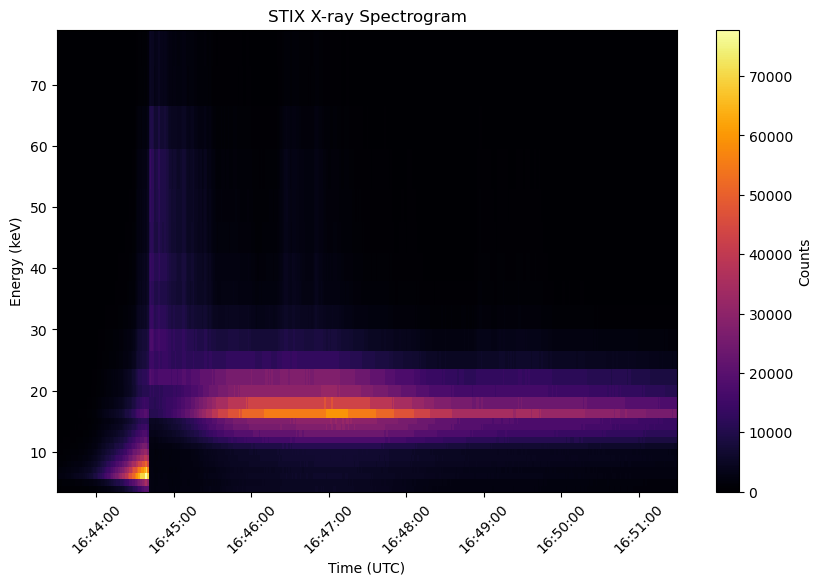

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time



# Getting Compressed pixel data(cpd)

from stixpy.product import Product

sci_files = sorted(sci_files)

spec = Product(sci_files[-2])
spec


import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time
import matplotlib.dates as mdates  # For UTC time formatting

# **Extract data**
time = Time(spec.data['time'])  # Convert time to Time object
time_utc = time.datetime  # Convert to Python datetime (for plotting)

counts = spec.data['counts']  # Shape: (1185, 32, 8, 31) with units
e_low = np.array(spec.energies['e_low'])  # Energy lower bounds
e_high = np.array(spec.energies['e_high'])  # Energy upper bounds

# **Sum counts over detectors and pixels to get (time, energy) shape**
counts_summed = counts # Shape: (1185, 31) with units

# **Remove NaN values from e_high**
valid_energy_mask = ~np.isnan(e_high)
e_low = e_low[valid_energy_mask]
e_high = e_high[valid_energy_mask]
counts_summed = counts_summed[:, valid_energy_mask]  # Apply the same filter

# **Define the time and energy range**
time_start = Time('2024-05-14T16:43:30')
time_end = Time('2024-05-14T16:51:30')

energy_min = 4.0  # keV
energy_max = 84.0  # keV

# **Filter time indices**
time_mask = (time >= time_start) & (time <= time_end)
filtered_time = np.array(time_utc)[time_mask]  # Convert to array of datetime objects

# **Filter energy indices**
energy_mask = (e_low >= energy_min) & (e_high <= energy_max)
filtered_e_low = e_low[energy_mask]
filtered_e_high = e_high[energy_mask]

# **Convert counts to a unitless array to avoid UnitConversionError**
filtered_counts = counts_summed[time_mask, :][:, energy_mask].value

# **Create a 2D meshgrid for pcolormesh**
time_grid, energy_grid = np.meshgrid(filtered_time, filtered_e_low)

# **Plot the spectrogram**
plt.figure(figsize=(10, 6))
plt.pcolormesh(time_grid, energy_grid, filtered_counts.T, shading='auto', cmap='inferno')
plt.colorbar(label='Counts')

# **Format the x-axis with UTC time**
plt.xlabel("Time (UTC)")
plt.ylabel("Energy (keV)")
plt.title("STIX X-ray Spectrogram")

# **Improve x-axis formatting**
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))  # Show only time
plt.xticks(rotation=45)

plt.show()


In [17]:
# Print shapes for debugging
print("Counts Shape:", counts.shape)  # (num_times, num_energy_bins)
print("E_low Shape:", e_low.shape)  # Should match counts.shape[1] - 1 if there's an extra bin
print("E_high Shape:", e_high.shape)  # Should match counts.shape[1] - 1 if there's an extra bin
print(counts_summed.shape
      )

Counts Shape: (15248, 32)
E_low Shape: (31,)
E_high Shape: (31,)
(15248, 31)


In [6]:
print("Counts shape:", counts.shape)


Counts shape: (15248, 32)


Counts shape: (1543, 32, 8, 31)


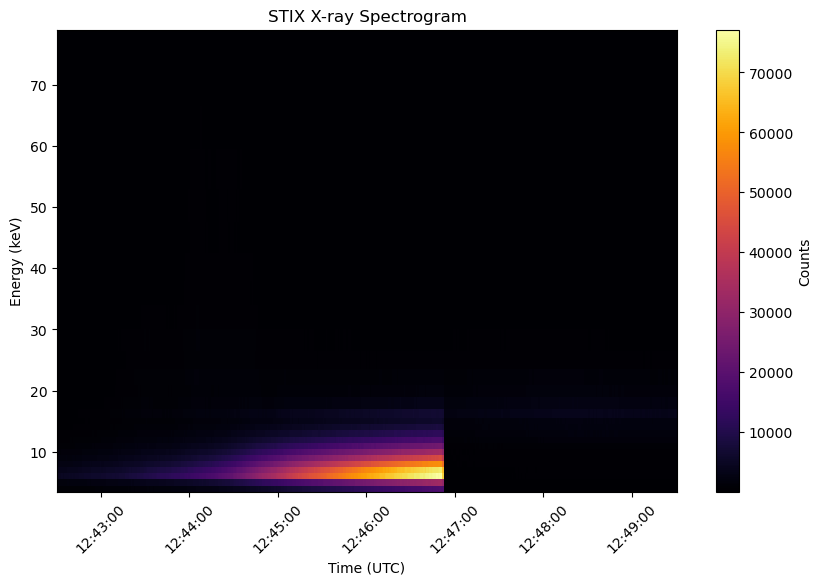

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time
import matplotlib.dates as mdates  # For UTC time formatting



# Getting Compressed pixel data(cpd)

from stixpy.product import Product

sci_files = sorted(sci_files)

spec = Product(sci_files[13])
spec




# **Extract data**
time = Time(spec.data['time'])  # Convert time to Time object
time_utc = time.datetime  # Convert to Python datetime (for plotting)

counts = spec.data['counts']  # Shape: (1185, 32, 8, 31) with units
e_low = np.array(spec.energies['e_low'])  # Energy lower bounds
e_high = np.array(spec.energies['e_high'])  # Energy upper bounds

print("Counts shape:", counts.shape)

# **Sum counts over detectors and pixels to get (time, energy) shape**
counts_summed = counts.sum(axis=(1, 2)) # Shape: (1185, 31) with units

# **Remove NaN values from e_high**
valid_energy_mask = ~np.isnan(e_high)
e_low = e_low[valid_energy_mask]
e_high = e_high[valid_energy_mask]
counts_summed = counts_summed[:, valid_energy_mask]  # Apply the same filter

# **Define the time and energy range**
time_start = Time('2024-05-14T12:42:30')
time_end = Time('2024-05-14T12:49:30')

energy_min = 4.0  # keV
energy_max = 84.0  # keV

# **Filter time indices**
time_mask = (time >= time_start) & (time <= time_end)
filtered_time = np.array(time_utc)[time_mask]  # Convert to array of datetime objects

# **Filter energy indices**
energy_mask = (e_low >= energy_min) & (e_high <= energy_max)
filtered_e_low = e_low[energy_mask]
filtered_e_high = e_high[energy_mask]

# **Convert counts to a unitless array to avoid UnitConversionError**
filtered_counts = counts_summed[time_mask, :][:, energy_mask].value

# **Create a 2D meshgrid for pcolormesh**
time_grid, energy_grid = np.meshgrid(filtered_time, filtered_e_low)

# **Plot the spectrogram**
plt.figure(figsize=(10, 6))
plt.pcolormesh(time_grid, energy_grid, filtered_counts.T, shading='auto', cmap='inferno')
plt.colorbar(label='Counts')

# **Format the x-axis with UTC time**
plt.xlabel("Time (UTC)")
plt.ylabel("Energy (keV)")
plt.title("STIX X-ray Spectrogram")

# **Improve x-axis formatting**
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))  # Show only time
plt.xticks(rotation=45)

plt.show()


In [25]:
# Print shapes for debugging

print("Counts Shape:", counts.shape)  # (num_times, num_energy_bins)
print("E_low Shape:", e_low.shape)  # Should match counts.shape[1] - 1 if there's an extra bin
print("E_high Shape:", e_high.shape)  # Should match counts.shape[1] - 1 if there's an extra bin
print(counts_summed.shape)

print("Energy mask sum:", np.sum(energy_mask))
print("Filtered counts shape:", filtered_counts.shape)

Counts Shape: (93, 32, 8, 17)
E_low Shape: (17,)
E_high Shape: (17,)
(93, 17)
Energy mask sum: 17
Filtered counts shape: (0, 17)


Time range in data: 2024-05-14 12:36:07.959 to 2024-05-14 13:01:49.959


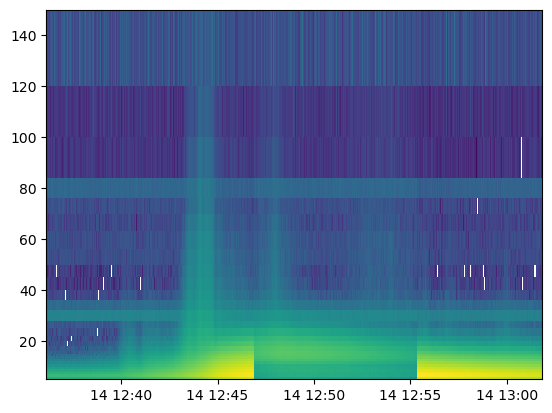

In [36]:
print("Time range in data:", time[0].iso, "to", time[-1].iso)

spec.plot_spectrogram()

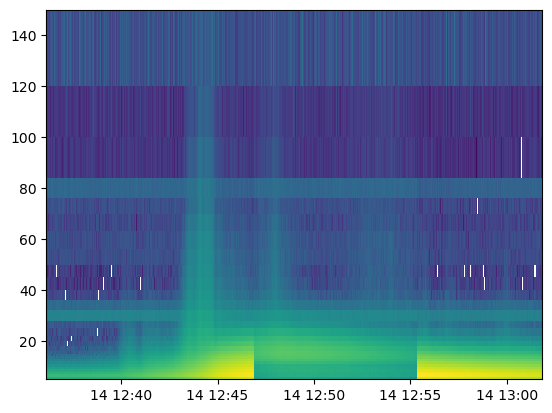

In [42]:
from astropy.time import Time

# Define your desired time window
time_start = Time('2024-05-14T12:42:30')
time_end = Time('2024-05-14T12:49:30')

# Apply the time mask
time_mask = (Time(spec.data['time'])  >= time_start) & (Time(spec.data['time']) <= time_end)

# Now use it to filter your time and counts
filtered_time = Time(spec.data['time'])[time_mask].datetime
filtered_counts = spec.data['counts'][time_mask]  # shape: (time, energy)


spec.plot_spectrogram()


In [41]:
print(filtered_time.shape)
print(filtered_counts.shape)

(420,)
(420, 32, 8, 31)


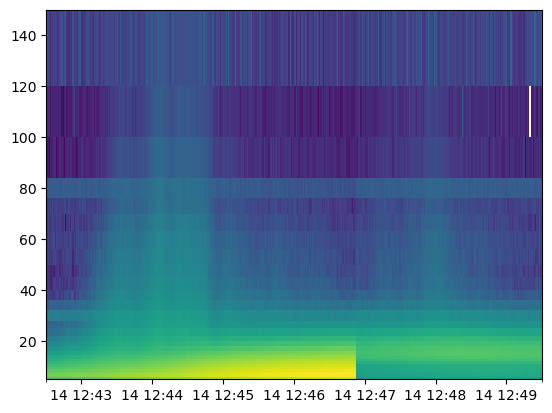

In [44]:
from astropy.time import Time

# Define the time range
start_time = Time('2024-05-14T12:42:30')
end_time = Time('2024-05-14T12:49:30')

# Convert all times in the data to astropy Time object
times = Time(spec.data['time'])

# Create a time mask and extract indices
time_mask = (times >= start_time) & (times <= end_time)
time_indices = np.where(time_mask)[0]

# Plot spectrogram with selected time indices
spec.plot_spectrogram(time_indices=time_indices)


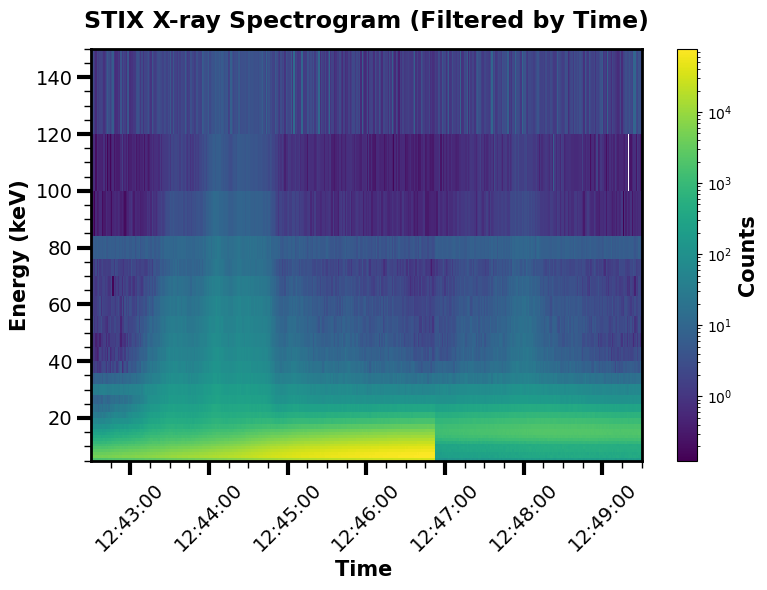

Duration: 0.004861111111111205


In [65]:
import matplotlib.pyplot as plt
from astropy.time import Time
import numpy as np

# Define time range
start_time = Time('2024-05-14T12:42:30')
end_time = Time('2024-05-14T12:49:30')

# Extract time indices from spec
times = Time(spec.data['time'])
time_mask = (times >= start_time) & (times <= end_time)
time_indices = np.where(time_mask)[0]

# Create figure and axes
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the spectrogram for selected time range
mesh = spec.plot_spectrogram(axes=ax, time_indices=time_indices)

# Add colorbar
cbar = plt.colorbar(mesh, ax=ax )
cbar.set_label("Counts", fontsize=15, fontweight='bold')

# **Format X-axis to show only time (hh:mm:ss)**
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))  

# **Make Axis Borders (Spines) Thicker**
ax.spines["top"].set_linewidth(2)      # Top border
ax.spines["right"].set_linewidth(2)    # Right border
ax.spines["left"].set_linewidth(2)     # Left border
ax.spines["bottom"].set_linewidth(2)   # Bottom border

# **Enable Minor Ticks for Better Precision**
ax.minorticks_on()  

# **Make Major and Minor Ticks Thicker**
ax.tick_params(axis='both', which='major', direction='out', length=8, width=2, labelsize=14)  # Major ticks
ax.tick_params(axis='both', which='minor', direction='out', length=5, width=1)  # Minor ticks (Thicker)

ax.xaxis.set_tick_params(width=3, length=10)  # Thicker X-axis ticks
ax.yaxis.set_tick_params(width=3, length=10)  # Thicker Y-axis ticks

# Format and label axes
ax.set_xlabel("Time ", fontsize=15, fontweight='bold')
ax.set_ylabel("Energy (keV)", fontsize=15, fontweight='bold')
ax.set_title("STIX X-ray Spectrogram (Filtered by Time)", fontsize=17, fontweight='bold', pad=15)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Calculate duration
duration = end_time-start_time
print("Duration:", duration) 

